# Exploração inicial do dataset de consumo de água

Este notebook apresenta uma exploração inicial do dataset de consumo de água disponibilizado no repositório do projeto.

Objetivos desta exploração:

- compreender a estrutura do dataset;
- identificar variáveis relevantes para análise;
- avaliar a qualidade dos dados;
- observar o comportamento temporal das séries;
- realizar uma análise estatística inicial dos consumos.

In [47]:
import os
import zipfile
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import autocorrelation_plot

plt.rcParams["figure.figsize"] = (12, 4)
sns.set_theme(style="whitegrid")

In [48]:
repo_datasets_path = Path("../PM2025-TSAnomalyDetection/example-timeseries")

repo_datasets_path

WindowsPath('../PM2025-TSAnomalyDetection/example-timeseries')

In [49]:
os.listdir(repo_datasets_path)

['aqualog.zip',
 'aqualog_11_2025.csv.zip',
 'Consumo15m.zip',
 'consumo15m_11_2025.csv.zip',
 'meteo_11_2025.csv.zip',
 'stcp.zip']

In [50]:
zip_path = repo_datasets_path / "aqualog_11_2025.csv.zip"

zip_path

WindowsPath('../PM2025-TSAnomalyDetection/example-timeseries/aqualog_11_2025.csv.zip')

In [51]:
with zipfile.ZipFile(zip_path) as z:
    print(z.namelist())

['aqualog_11_2025.csv']


In [52]:
with zipfile.ZipFile(zip_path) as z:
    with z.open(z.namelist()[0]) as f:
        df_agua = pd.read_csv(f)

In [53]:
df_agua.head()

,tstamp,device,valor_l,leitura_l
0,2024-11-08 23:00:00,00PC503015,0,3462110
1,2024-11-08 22:00:00,00PC503015,0,3462110
2,2024-11-08 21:00:00,00PC503015,0,3462110
3,2024-11-08 20:00:00,00PC503015,0,3462110
4,2024-11-08 19:00:00,00PC503015,0,3462110


In [54]:
df_agua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2603234 entries, 0 to 2603233
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   tstamp     object
 1   device     object
 2   valor_l    int64 
 3   leitura_l  int64 
dtypes: int64(2), object(2)
memory usage: 79.4+ MB


In [55]:
df_agua.shape

(2603234, 4)

In [56]:
df_agua.columns

Index(['tstamp', 'device', 'valor_l', 'leitura_l'], dtype='object')

### Estrutura do dataset

O dataset contém as seguintes colunas principais:

- **tstamp**: instante temporal da medição;
- **device**: identificador do contador/dispositivo;
- **valor_l**: volume consumido no intervalo, em litros;
- **leitura_l**: leitura acumulada do contador, em litros.

Nesta fase, a variável principal considerada para análise será **valor_l**, por representar o consumo observado em cada instante/intervalo.

In [57]:
df_agua["tstamp"] = pd.to_datetime(df_agua["tstamp"])

In [58]:
df_agua = df_agua.sort_values("tstamp")

In [59]:
print("Início:", df_agua["tstamp"].min())
print("Fim:", df_agua["tstamp"].max())

Início: 2024-09-18 01:00:00
Fim: 2025-10-24 00:59:00


In [60]:
df_agua["device"].nunique()

456

In [61]:
df_agua.isna().sum()

tstamp       0
device       0
valor_l      0
leitura_l    0
dtype: int64

In [62]:
df_agua[["valor_l", "leitura_l"]].describe()

,valor_l,leitura_l
count,2.603234e+06,2.603234e+06
mean,6.755759e+01,4.647876e+06
std,4.402679e+02,1.250585e+07
min,-3.105800e+04,-4.330000e+04
25%,0.000000e+00,1.044770e+05
50%,0.000000e+00,8.037010e+05
75%,8.000000e+00,3.298920e+06
max,3.706110e+05,1.633660e+08


### Observações iniciais

A análise exploratória inicial permite identificar:

- o intervalo temporal coberto pelo dataset;
- o número de dispositivos distintos monitorizados;
- a presença de eventuais valores em falta;
- estatísticas básicas das variáveis de consumo e leitura acumulada.

A variável **valor_l** será utilizada como variável principal, por representar diretamente o consumo de água.

### Visualização exploratória global

O gráfico seguinte mostra os valores de **valor_l** ao longo do tempo para todos os dispositivos.

Tal como no caso do dataset de energia, este gráfico serve sobretudo para perceber a escala global dos dados e a densidade temporal dos registos.

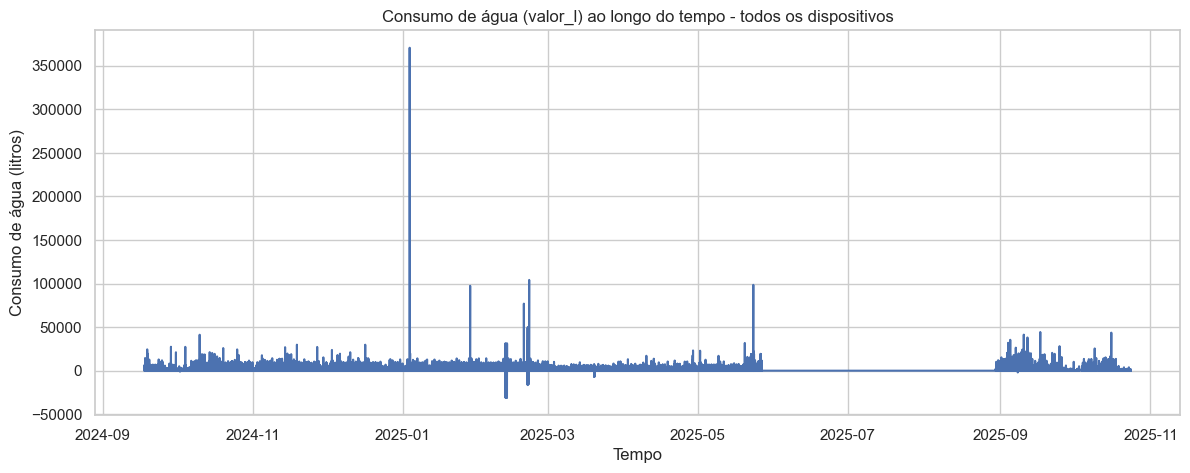

In [63]:
plt.figure(figsize=(14, 5))

plt.plot(df_agua["tstamp"], df_agua["valor_l"])

plt.title("Consumo de água (valor_l) ao longo do tempo - todos os dispositivos")
plt.xlabel("Tempo")
plt.ylabel("Consumo de água (litros)")

plt.show()

In [64]:
df_pivot_agua = df_agua.pivot_table(
    index="tstamp",
    columns="device",
    values="valor_l"
)

df_pivot_agua.head()

device,00PC503015,10045021,2124881J,94CWK04576,97WWK12134,98WWKI12645,C15FA534254,C15SC004730,C16SB066962U,C16SC000825R,...,I24LA025413,I24LA025871,I24LA025880,I24LA026648,I24LA027028,I24LA028096,I24LA028098,I24LA028157,I24LA028258,I24LA029109
tstamp,,,,,,,,,,,,,,,,,,,,,
2024-09-18 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-18 01:01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-18 01:02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-18 01:04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-18 01:07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
df_pivot_agua.shape

(394876, 456)

In [66]:
missing_pct_agua = df_pivot_agua.isna().mean() * 100

missing_pct_agua.sort_values().head(10)

device
97WWK12134      98.228811
C17SC007397     98.255655
C18SC002133     98.265278
98WWKI12645     98.274142
C17SC007432     98.274395
I21JC037663T    98.274648
C17SC007379     98.274901
00PC503015      98.275155
I14JE002622G    98.275661
H21VA420783K    98.281739
dtype: float64

In [67]:
device_exemplo = missing_pct_agua.sort_values().index[0]

device_exemplo

'97WWK12134'

In [68]:
serie_exemplo_agua = df_pivot_agua[device_exemplo]

serie_exemplo_agua.head()

tstamp
2024-09-18 01:00:00   NaN
2024-09-18 01:01:00   NaN
2024-09-18 01:02:00   NaN
2024-09-18 01:04:00   NaN
2024-09-18 01:07:00   NaN
Name: 97WWK12134, dtype: float64

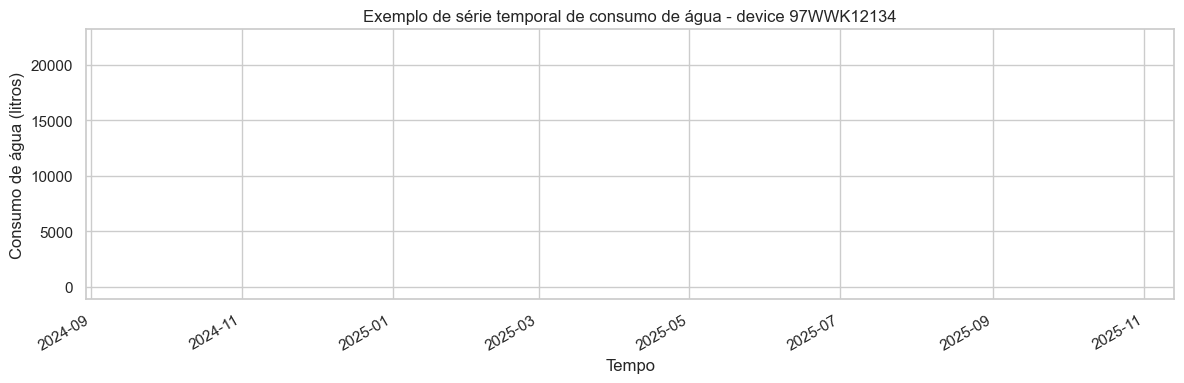

In [69]:
plt.figure(figsize=(12, 4))

serie_exemplo_agua.plot()

plt.title(f"Exemplo de série temporal de consumo de água - device {device_exemplo}")
plt.xlabel("Tempo")
plt.ylabel("Consumo de água (litros)")

plt.tight_layout()
plt.show()

In [70]:
df_pivot_agua.index.to_series().diff().value_counts().head()

tstamp
0 days 00:01:00    367225
0 days 00:02:00     21834
0 days 00:03:00      2502
0 days 00:04:00      1006
0 days 00:05:00       989
Name: count, dtype: int64

## Análise estatística inicial

Para complementar a exploração anterior, seguem-se algumas análises estatísticas descritivas do dataset de água, incluindo consumos médios, agregações diárias e distribuição dos valores.

In [71]:
print("Número total de registos:", len(df_agua))
print("Número de devices distintos:", df_agua["device"].nunique())
print("Período temporal:", df_agua["tstamp"].min(), "até", df_agua["tstamp"].max())

Número total de registos: 2603234
Número de devices distintos: 456
Período temporal: 2024-09-18 01:00:00 até 2025-10-24 00:59:00


In [72]:
estatisticas_globais_agua = df_agua["valor_l"].describe()
estatisticas_globais_agua

count    2.603234e+06
mean     6.755759e+01
std      4.402679e+02
min     -3.105800e+04
25%      0.000000e+00
50%      0.000000e+00
75%      8.000000e+00
max      3.706110e+05
Name: valor_l, dtype: float64

In [73]:
consumo_medio_por_device = df_pivot_agua.mean().sort_values(ascending=False)
consumo_medio_por_device.head(10)

device
C22FE011961V    1700.879071
D12XF094973V    1490.067638
I22JC094277O    1313.846529
I19MF927865      949.152652
I19JC029846L     875.778412
C18SC002113      863.875333
C21FE010289Z     770.745598
I21JC029465S     655.708150
D16XF077374      619.219813
D10OF068767      594.154326
dtype: float64

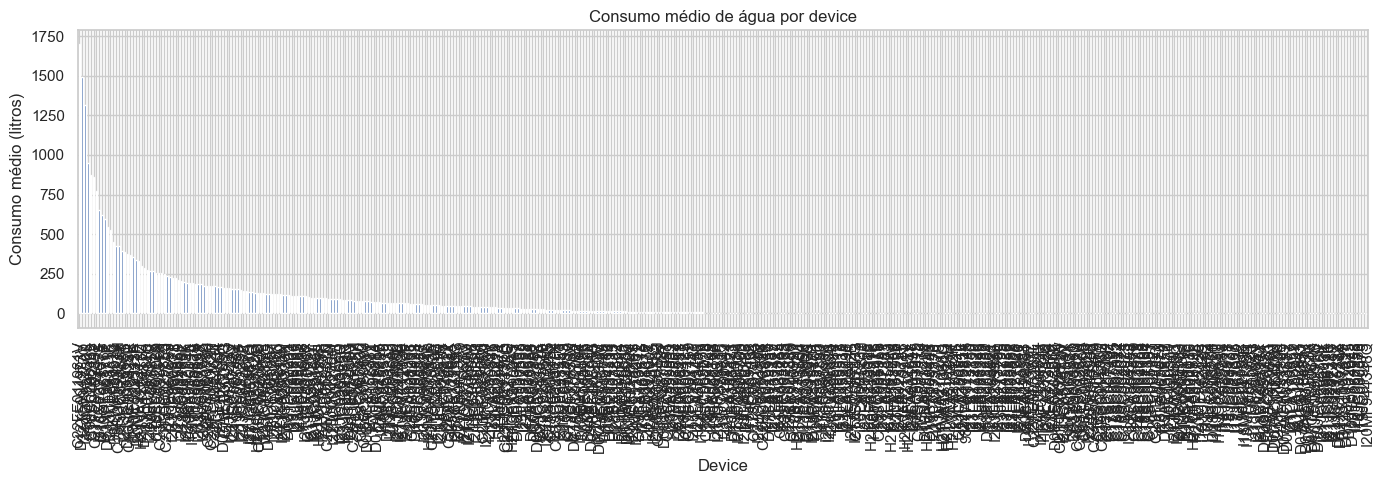

In [74]:
plt.figure(figsize=(14, 5))
consumo_medio_por_device.plot(kind="bar")
plt.title("Consumo médio de água por device")
plt.xlabel("Device")
plt.ylabel("Consumo médio (litros)")
plt.tight_layout()
plt.show()

In [75]:
consumo_medio_global_agua = df_pivot_agua.mean().mean()
print("Consumo médio global:", consumo_medio_global_agua)

Consumo médio global: 67.58883522757903


In [76]:
consumo_diario_agua = df_pivot_agua.resample("D").sum()
consumo_diario_agua.head()

device,00PC503015,10045021,2124881J,94CWK04576,97WWK12134,98WWKI12645,C15FA534254,C15SC004730,C16SB066962U,C16SC000825R,...,I24LA025413,I24LA025871,I24LA025880,I24LA026648,I24LA027028,I24LA028096,I24LA028098,I24LA028157,I24LA028258,I24LA029109
tstamp,,,,,,,,,,,,,,,,,,,,,
2024-09-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-09-19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-09-20,0.0,0.0,3412.0,0.0,0.0,0.0,0.0,0.0,0.0,6037.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-09-21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7977.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-09-22,0.0,0.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,2815.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


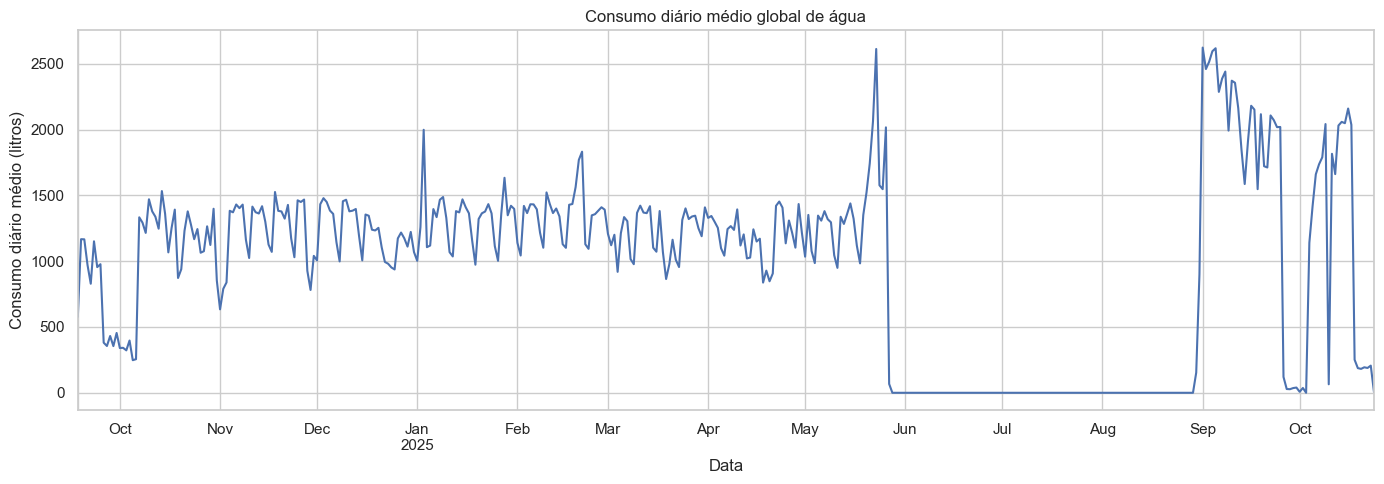

In [77]:
plt.figure(figsize=(14, 5))
consumo_diario_agua.mean(axis=1).plot()
plt.title("Consumo diário médio global de água")
plt.xlabel("Data")
plt.ylabel("Consumo diário médio (litros)")
plt.tight_layout()
plt.show()

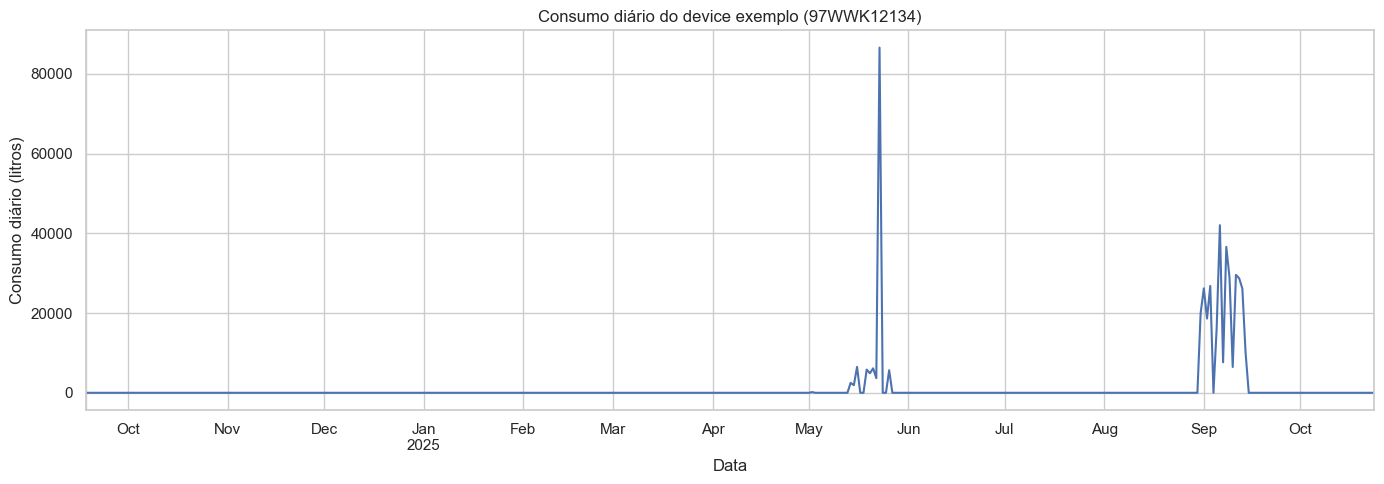

In [78]:
plt.figure(figsize=(14, 5))
consumo_diario_agua[device_exemplo].plot()
plt.title(f"Consumo diário do device exemplo ({device_exemplo})")
plt.xlabel("Data")
plt.ylabel("Consumo diário (litros)")
plt.tight_layout()
plt.show()

In [79]:
consumo_medio_diario_por_device = consumo_diario_agua.mean().sort_values(ascending=False)
consumo_medio_diario_por_device.head(10)

device
C22FE011961V    27150.599502
I22JC094277O    21466.029851
D12XF094973V    21372.462687
I19MF927865     14600.895522
C18SC002113     13703.813433
C21FE010289Z    11869.865672
I21JC029465S    10747.415423
D10OF068767      9481.343284
D16XF077374      9376.097015
I19JC029846L     8779.569652
dtype: float64

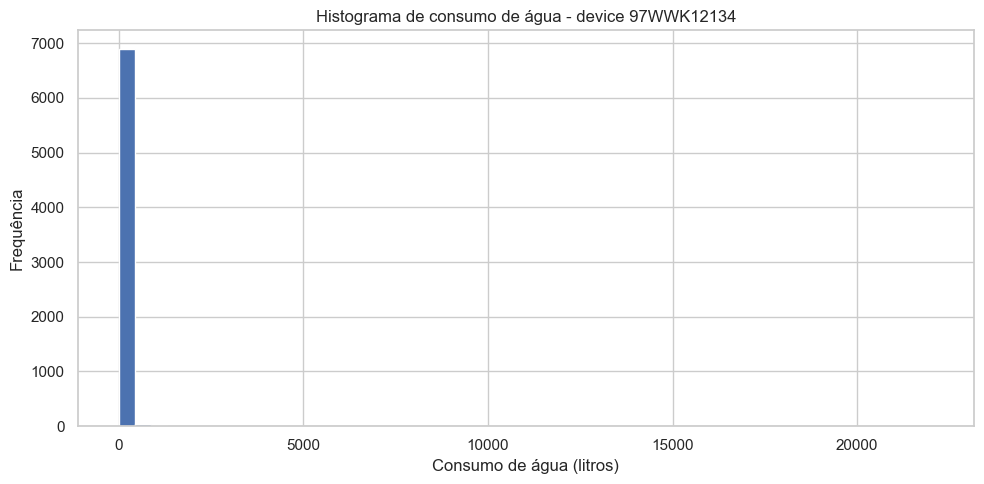

In [80]:
plt.figure(figsize=(10, 5))
plt.hist(serie_exemplo_agua.dropna(), bins=50)
plt.title(f"Histograma de consumo de água - device {device_exemplo}")
plt.xlabel("Consumo de água (litros)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

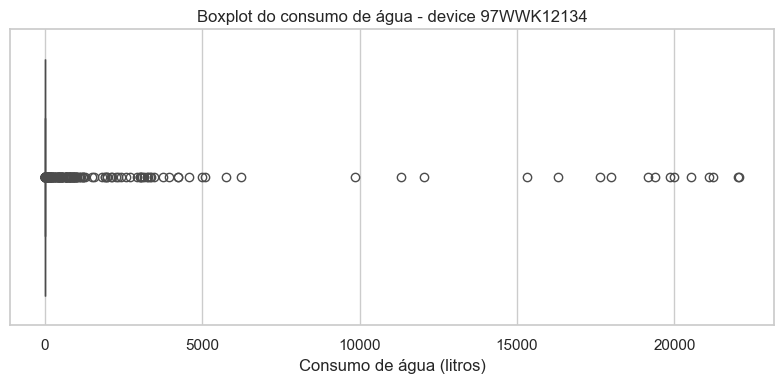

In [81]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=serie_exemplo_agua.dropna())
plt.title(f"Boxplot do consumo de água - device {device_exemplo}")
plt.xlabel("Consumo de água (litros)")
plt.tight_layout()
plt.show()

In [82]:
serie_exemplo_agua.describe()

count     6994.000000
mean        64.027738
std        904.787894
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      22060.000000
Name: 97WWK12134, dtype: float64

### Agregações temporais

As agregações seguintes ajudam a observar tendências e possíveis padrões sazonais em escalas temporais diferentes.

In [83]:
serie_exemplo_agua_diaria = serie_exemplo_agua.resample("D").mean()
serie_exemplo_agua_semanal = serie_exemplo_agua.resample("W").mean()
serie_exemplo_agua_mensal = serie_exemplo_agua.resample("M").mean()

C:\Users\gui30\AppData\Local\Temp\ipykernel_20252\2053029367.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  serie_exemplo_agua_mensal = serie_exemplo_agua.resample("M").mean()


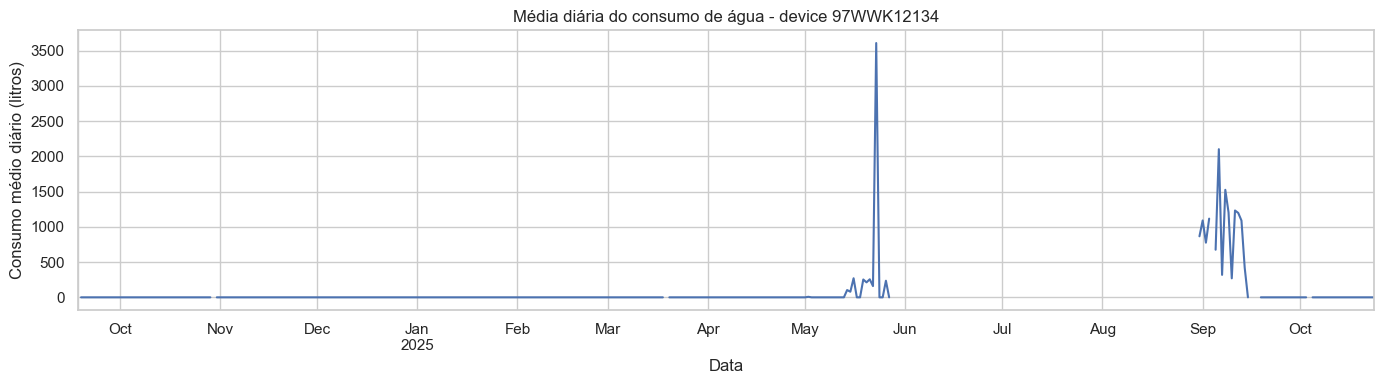

In [84]:
plt.figure(figsize=(14, 4))
serie_exemplo_agua_diaria.plot()
plt.title(f"Média diária do consumo de água - device {device_exemplo}")
plt.xlabel("Data")
plt.ylabel("Consumo médio diário (litros)")
plt.tight_layout()
plt.show()

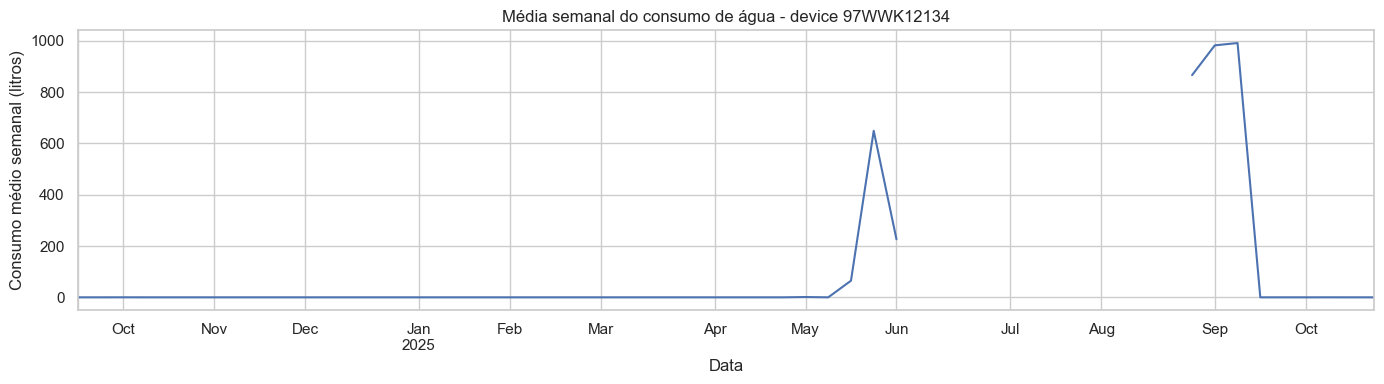

In [85]:
plt.figure(figsize=(14, 4))
serie_exemplo_agua_semanal.plot()
plt.title(f"Média semanal do consumo de água - device {device_exemplo}")
plt.xlabel("Data")
plt.ylabel("Consumo médio semanal (litros)")
plt.tight_layout()
plt.show()

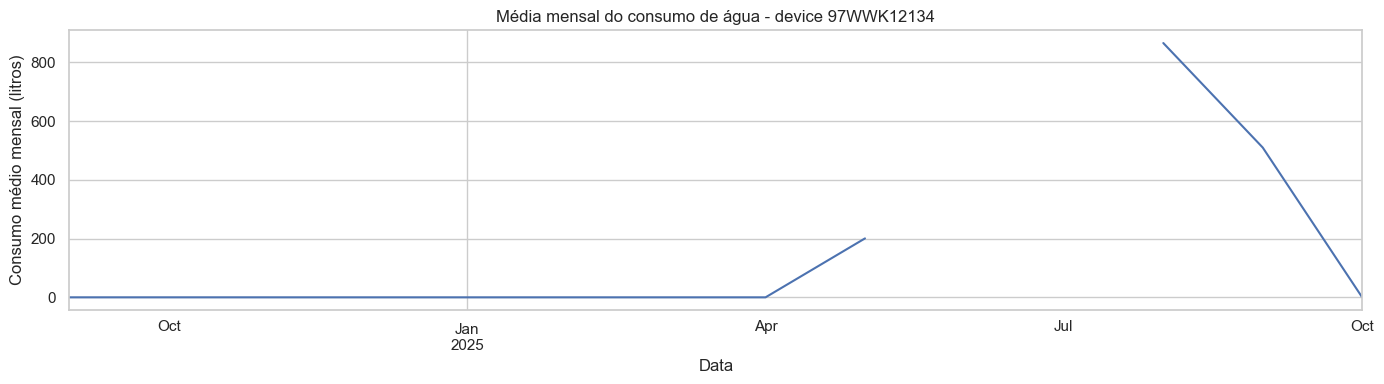

In [86]:
plt.figure(figsize=(14, 4))
serie_exemplo_agua_mensal.plot()
plt.title(f"Média mensal do consumo de água - device {device_exemplo}")
plt.xlabel("Data")
plt.ylabel("Consumo médio mensal (litros)")
plt.tight_layout()
plt.show()

### Autocorrelação

A autocorrelação permite observar dependências temporais na série, sendo útil para perceber se existem padrões regulares de repetição também no consumo de água.

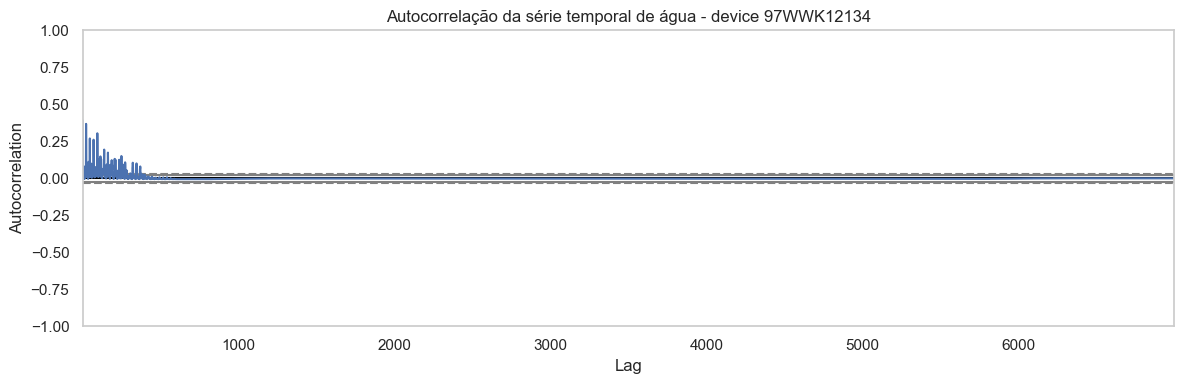

In [87]:
plt.figure(figsize=(12, 4))
autocorrelation_plot(serie_exemplo_agua.dropna())
plt.title(f"Autocorrelação da série temporal de água - device {device_exemplo}")
plt.tight_layout()
plt.show()

In [88]:
freq_dominante_agua = df_pivot_agua.index.to_series().diff().value_counts().idxmax()
print("Frequência temporal dominante:", freq_dominante_agua)

Frequência temporal dominante: 0 days 00:01:00


In [89]:
valores_negativos_agua = (df_agua["valor_l"] < 0).sum()
print("Número de valores negativos em valor_l:", valores_negativos_agua)

Número de valores negativos em valor_l: 3648


### Verificação de valores negativos

Em séries de consumo de água, valores negativos podem indicar problemas de medição, resets de contador ou inconsistências nos dados.

Por isso, é relevante verificar a existência deste tipo de valores numa fase inicial da exploração.

In [90]:
valores_negativos_agua = (df_agua["valor_l"] < 0).sum()
print("Número de valores negativos em valor_l:", valores_negativos_agua)

Número de valores negativos em valor_l: 3648


### Atividade dos dispositivos ao longo do tempo

Para compreender melhor a cobertura temporal dos dispositivos,
analisa-se o número de devices ativos em cada instante temporal.
Este gráfico permite observar possíveis períodos com maior ou menor
atividade de dispositivos.

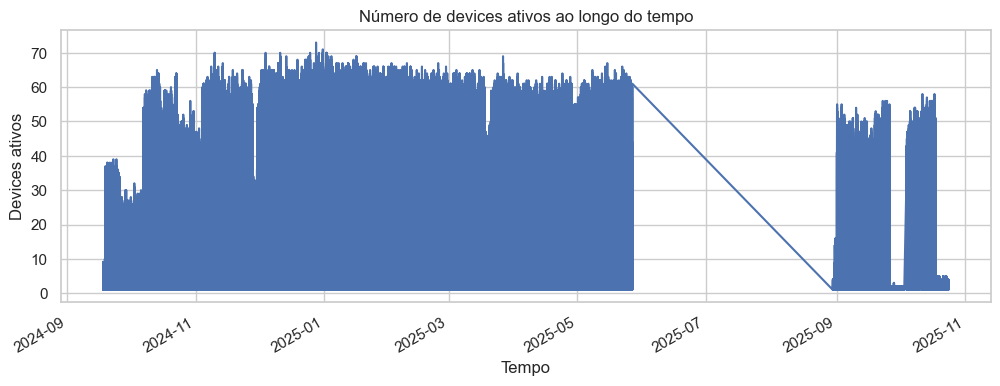

In [91]:
devices_ativos = df_agua.groupby("tstamp")["device"].nunique()

plt.figure(figsize=(12,4))
devices_ativos.plot()

plt.title("Número de devices ativos ao longo do tempo")
plt.xlabel("Tempo")
plt.ylabel("Devices ativos")

plt.show()

### Número de registos por dispositivo

A distribuição do número de registos por device permite avaliar
a heterogeneidade da cobertura temporal entre dispositivos.

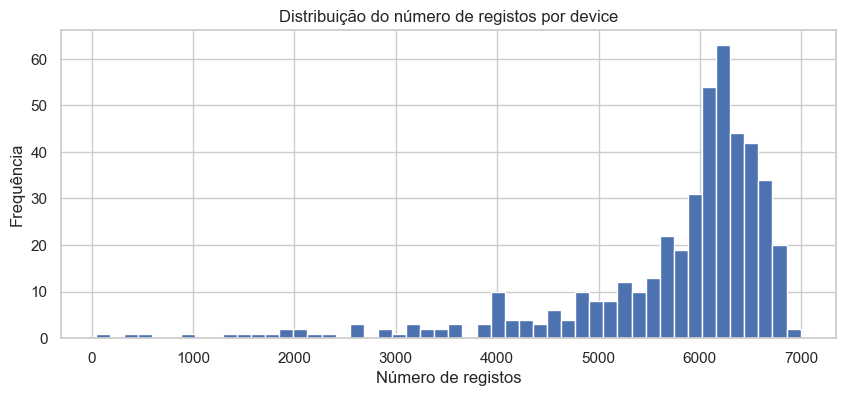

In [92]:
registos_por_device = df_agua.groupby("device").size()

plt.figure(figsize=(10,4))
plt.hist(registos_por_device, bins=50)

plt.title("Distribuição do número de registos por device")
plt.xlabel("Número de registos")
plt.ylabel("Frequência")

plt.show()

## Conclusões iniciais sobre o dataset de água

- O dataset contém medições temporais de consumo de água para múltiplos dispositivos.
- A variável **valor_l** foi selecionada como variável principal de análise, por representar o consumo observado.
- A variável **leitura_l** representa a leitura acumulada do contador e poderá ser útil em análises futuras de consistência.
- A análise estatística inicial permite observar diferenças entre dispositivos ao nível do consumo médio.
- Os histogramas e boxplots ajudam a identificar assimetrias, presença de muitos zeros e potenciais valores extremos.
- As agregações diárias, semanais e mensais permitem observar tendências temporais e padrões de utilização.
- A autocorrelação ajuda a perceber se existem comportamentos repetitivos no consumo.
- A verificação de valores negativos é relevante para deteção de possíveis problemas de qualidade dos dados.

In [93]:
estatisticas_por_device_agua = df_pivot_agua.describe().T
estatisticas_por_device_agua.to_csv("../results/estatisticas_por_device_agua.csv")

missing_pct_agua.sort_values().to_csv("../results/missing_pct_por_device_agua.csv")
consumo_medio_por_device.to_csv("../results/consumo_medio_por_device_agua.csv")
consumo_medio_diario_por_device.to_csv("../results/consumo_medio_diario_por_device_agua.csv")